# Task 1

## 1) Data retrieval and collection

The first step in the Machine Learning pipeline is to get and collect data. We do this by loading the dataset and looking at it to see what it is made of. We want to know some things about the data like how many rows and columns it has what the features are called and what some of the records look like.

For this project we are using the Salary Dataset. This dataset has an important things in it including:
-YearsExperience, which is the input we use to make predictions
-Salary, which is the thing we are trying to predict also called the target variable

Our goal with the Salary Dataset is to figure out how to predict someones salary based on how years they have been working.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#load dataset

import pandas as pd

data = pd.read_csv("Salary_Data.csv")
experience=data['YearsExperience'].values
salary=data['Salary'].values

In [3]:
#Display basic information (shape, column names)

print("Experience shape",experience.shape)
print("Shape of dataset:",data.shape)

print("Columns:",data.columns.tolist())

Experience shape (30,)
Shape of dataset: (30, 2)
Columns: ['YearsExperience', 'Salary']


## 2) Data cleaning

We need to clean up the data to make sure it is correct and good for training a model. The raw data we get often has problems like missing information, duplicate entries, wrong types of data or things that do not match.

We do these checks to make sure everything is okay:
-Missing value detection
-Duplicate record detection
-Data type verification

In the data we are working with there are no missing values. If there were missing values we could deal with them by:
1. Removing the entries that're not complete
2. Replacing the numbers with the average or the middle value (mean or median)
3. Replacing the categories with the common one

After we clean up the data it is ready for us to look at and use to build a model. The data cleaning process is important for the dataset because it helps us get results, from the model training. The dataset is cleaned to prepare it for analysis and model building.

In [4]:
print(data.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


There are no missing values

If there were any missing values, it can be either dropped or filled with it's mean or median( for numerical) and mode(for categorical)

data=data.dropna()

data.fillna(data.mean(),inplace=True)

In [5]:
#verify data types

print(data.dtypes)

YearsExperience    float64
Salary               int64
dtype: object


In [6]:
#scaling data

from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

experience_scaled = x_scaler.fit_transform(
    experience.reshape(-1,1)
)

salary_scaled = y_scaler.fit_transform(
    salary.reshape(-1,1)
)

salary_scaled = salary_scaled.reshape(-1)


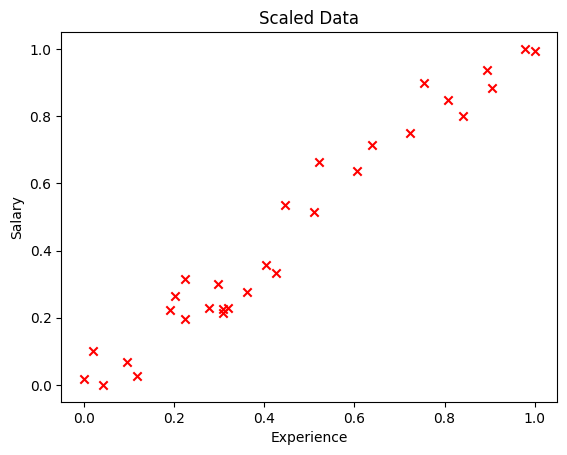

In [7]:
#visualize

plt.scatter(
    experience_scaled,
    salary_scaled,
    marker='x',
    color='red'
)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Scaled Data")
plt.show()


## 3) Feature Deisgn

When we are designing a feature we need to pick the input variables that we will use to make a prediction. We also need to separate these variables from the target variable that we are trying to predict. For this task we have a feature which is YearsExperience and a target which is Salary. We do not need to do any work, on the feature because the dataset we are using only has one variable that helps us make a prediction. The feature we have chosen is directly connected to predicting Salary. We might also want to adjust the values of the feature to make sure the numbers are stable when we are training the model. This can help when we are using a method called descent to train the model.

In [8]:
X_scaled = np.column_stack(
    (
        np.ones(len(experience_scaled)),
        experience_scaled.flatten()
    )
)

y_scaled = salary_scaled

print(X_scaled.shape)
print(y_scaled.shape)

(30, 2)
(30,)


## 4) Algorithm selection

Linear Regression is chosen because the target variable, Salary is a number. The aim is to model how salary relates to years of experience, with a straight line.

Linear regression uses:
ŷ = θ₀ + θ₁x

where
 x= YearsExperience
 ŷ= predicted salary
 θ₀= intercept
 θ₁= slope

 Here we have to predict continuous numerical value i.e salary from YearsEcperience as the input feature which makes this a regression problem. The data points plotted on a graph show that as experience increases salary tends to increase which is why Linear Regression works well here.


## 5) Loss function selection

The loss function shows us how different the model predictions are from the values. When we train the model we want to make this loss as small as possible. We do this so the model predictions are close to the values. The loss function is important because it helps us see how well the model is doing. The goal is to minimize the loss function. This means the model predictions and the actual values are very close, to each other. The model is doing a job when the loss is small.

Reasons for choosing Mean Squared Error (MSE):
-Larger mistakes get penalties. This is because bigger errors have an impact on the penalty.
-MSE provides a surface for optimization. This makes it easier to find the solution.
-It is widely used for regression problems.

The initial cost shows how wrong the predictions are before the model starts learning. It represents the error in the predictions, at the beginning.

In [9]:
def compute_cost(X, y, theta):

    predictions = np.matmul(X, theta)

    errors = predictions - y

    return np.sum(errors**2)/(2*len(y))

In [10]:
theta = np.zeros(2)

initial_cost = compute_cost(
    X_scaled,
    y_scaled,
    theta
)

print("Initial Cost:", initial_cost)

Initial Cost: 0.15286373365038744


initial cost is the value of loss function before training starts

## 6) Model Training


Model training is when a model learns the values for its parameters like theta 0 and theta 1 from the data we have. We use something called Gradient Descent to make sure the difference between what the model predicts and what actually happens is as small as possible. The training process is pretty simple. 
Here is what we do:
-We start by setting the parameters to zero.
-Then we use the model to make some predictions.
-Next we see how wrong those predictions are.
-We use that information to make the parameters a little better.
-We keep doing that until the model's really good at predicting.

As we train the model it gets better and better at finding the line that best fits the data. When the model is all trained we have the values, for the intercept, which is theta 0 and the slope, which is theta 1.

In [11]:
def gradient_descent(X, y, alpha, iterations):

    theta = np.zeros(2)

    m = len(y)

    for _ in range(iterations):

        predictions = np.dot(X, theta)

        errors = predictions - y

        t0 = theta[0] - (alpha/m) * np.sum(errors)

        t1 = theta[1] - (alpha/m) * np.sum(
            errors * X[:,1]
        )

        theta = np.array([t0, t1])

    return theta

In [12]:
iterations = 50000
alpha = 0.001

theta = gradient_descent(
    X_scaled,
    y_scaled,
    alpha,
    iterations
)

print("Theta:", theta)

print(
    "Final Cost:",
    compute_cost(
        X_scaled,
        y_scaled,
        theta
    )
)

Theta: [-0.00714777  1.0263057 ]
Final Cost: 0.002205014178641856


In [13]:
def predict_single(x, theta, x_scaler, y_scaler):

    x_scaled = x_scaler.transform([[x]])

    y_scaled = theta[1] * x_scaled + theta[0]

    y = y_scaler.inverse_transform(y_scaled)

    return y[0][0]

In [14]:
def predict_batch(X, theta, x_scaler, y_scaler):

    X = np.array(X).reshape(-1,1)

    X_scaled = x_scaler.transform(X)

    y_scaled = theta[1] * X_scaled + theta[0]

    y = y_scaler.inverse_transform(y_scaled)

    return y.flatten()

## 7) Model evaluation

Model evaluation is about checking how well a trained model works with a given dataset.

There are two metrics used for this:
-Mean Squared Error or MSE
MSE is a measure of the error in the models predictions. If the MSE is low the predictions are better. If the MSE is high the prediction errors are bigger.

-R² Score
The R² score shows how much of the variation in salary can be explained by years of experience.

The formula for R² is:

R² = 1 - (SSres / SStot)

Here's how to interpret the R² score:
-R² = 1 means the model is
-R² > 0.8 means the model is strong
-R² ≈ 0 means the model is weak

A high R² score means that years of experience is a good predictor of salary. The model is good, at predicting salary based on years of experience.



In [15]:
pred_salary = predict_batch(
    experience,
    theta,
    x_scaler,
    y_scaler
)


### MSE

In [16]:
mse = np.mean(
    (salary - pred_salary)**2
)

print("MSE =", mse)

MSE = 31608065.041601915


### R^2 score

In [17]:
from sklearn.metrics import r2_score

r2 = r2_score(
    salary,
    pred_salary
)

print("R² Score =", r2)

R² Score = 0.956492639832573


### Regression line visualzation

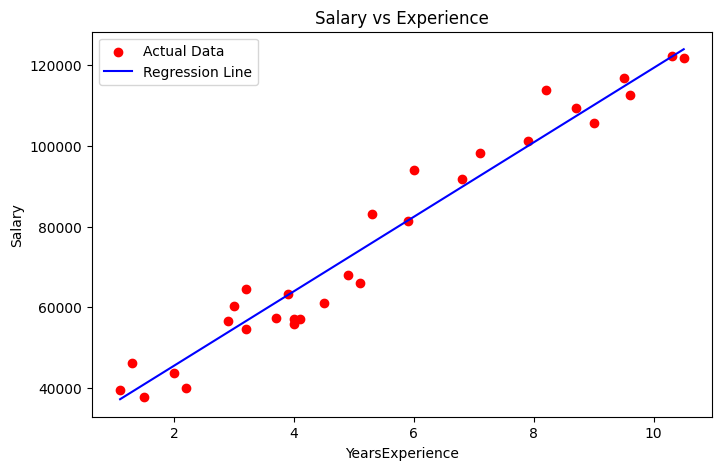

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    experience,
    salary,
    color='red',
    label='Actual Data'
)

sorted_idx = np.argsort(experience)

plt.plot(
    experience[sorted_idx],
    pred_salary[sorted_idx],
    color='blue',
    label='Regression Line'
)

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")

plt.legend()

plt.show()

### Actual vs Predicted visulaization

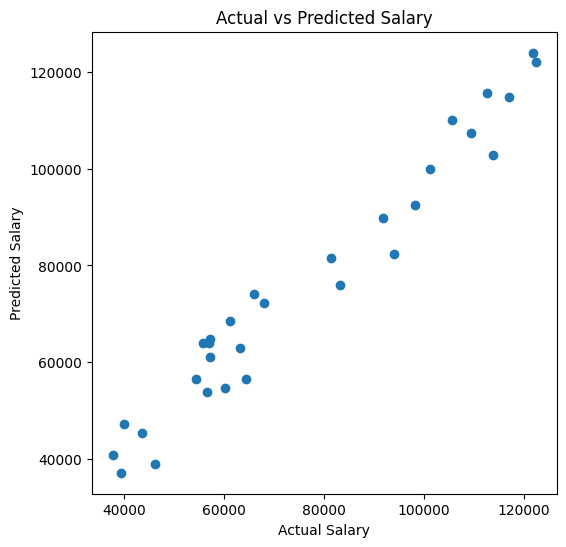

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(
    salary,
    pred_salary
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

## Model Interpretation 

Coefficient (Slope):
The coefficient shows how salary changes when experience goes up by one year.

For example if the coefficient is around 9424:
For every year of experience the predicted salary goes up by about $9,424.
A positive coefficient means that more experience usually means a salary.

Intercept
The intercept is the predicted salary when you have zero years of experience. Even if its unlikely that an employee would earn this amount with no experience the intercept is the starting point, for the regression equation.

## Discussion 

The results show that the more years of experience you have the higher your salary is likely to be. When you have experience your salary usually goes up too. The model we used to study this relationship does a job of showing how this works and makes pretty good predictions. The numbers we got from the model like the R² score and low error rate suggest that experience is really important when it comes to deciding how much money you make.. Experience is not the only thing that affects your salary. Other things, like what you studied what kind of job you have where you live what skills you have and what industry you work in can also make a difference. These things are not included in the information we looked at.

## Conclusion 

This assignment showed how to use Simple Linear Regression from start to finish. It covered collecting data cleaning it choosing the features picking an algorithm selecting a loss function training the model and evaluating it. The model I trained was good at predicting salary based on experience. It did well in making predictions. This exercise helped me understand how to build and evaluate regression models, in machine learning using Simple Linear Regression.

